Dataset loaded successfully: (1025, 14)
After removing duplicates: (302, 14)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


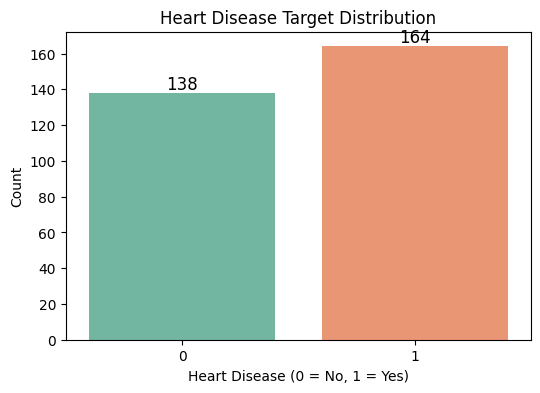


Preprocessing complete.
Training set: (241, 25) Test set: (61, 25)


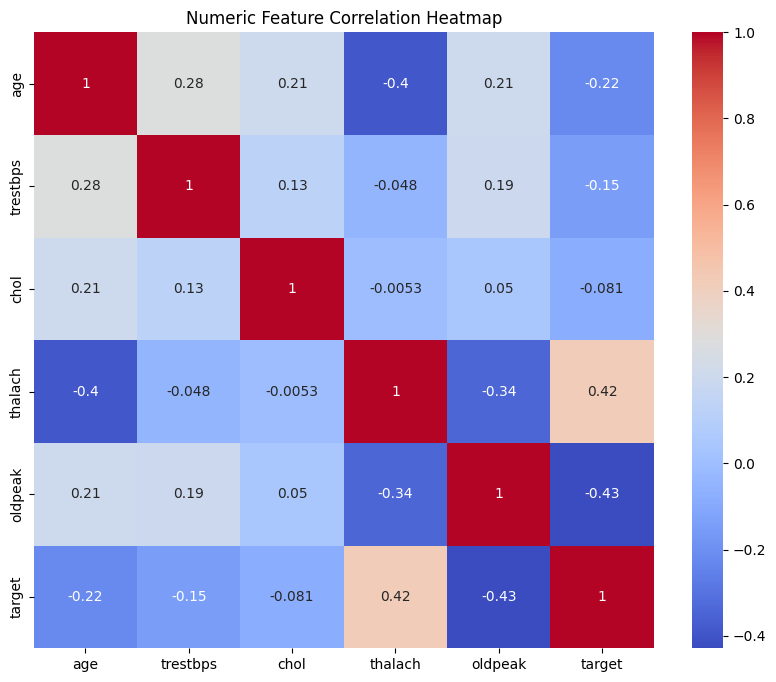

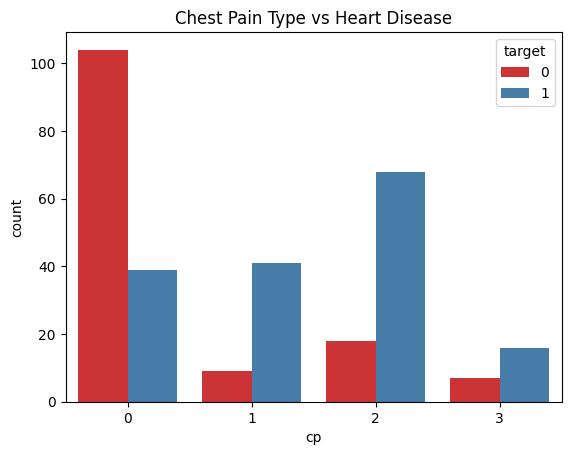

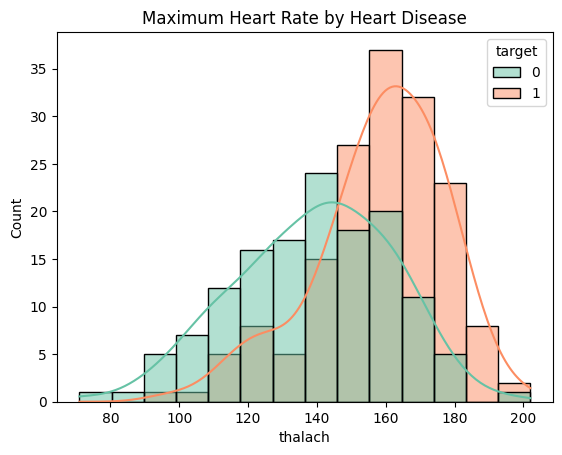

Best RF Params: {'max_depth': 8, 'n_estimators': 100}
Best SVM Params: {'C': 1, 'kernel': 'linear'}
Best XGBoost Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}

Model Performance Summary:

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.852459   0.875000  0.848485  0.861538  0.899351
1          Naive Bayes  0.819672   0.843750  0.818182  0.830769  0.911255
2        Random Forest  0.786885   0.833333  0.757576  0.793651  0.887446
3                  SVM  0.868852   0.878788  0.878788  0.878788  0.910173
4              XGBoost  0.786885   0.833333  0.757576  0.793651  0.850649


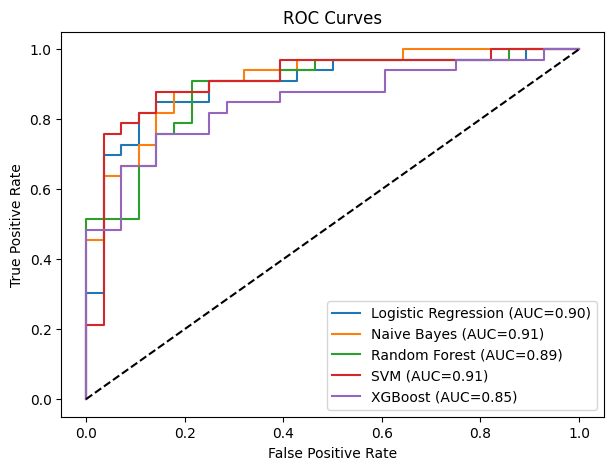

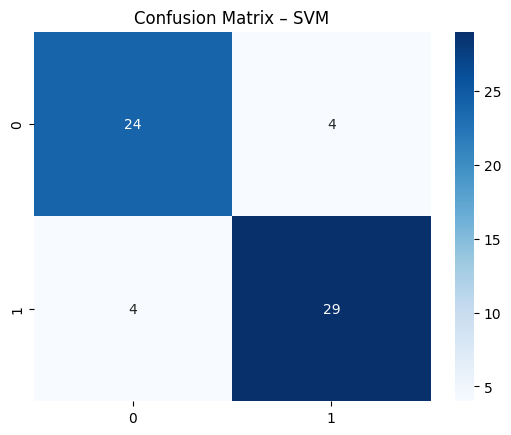

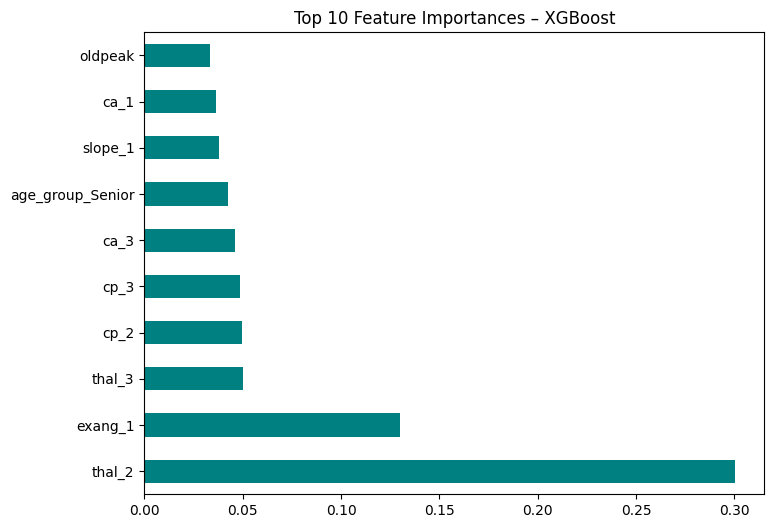

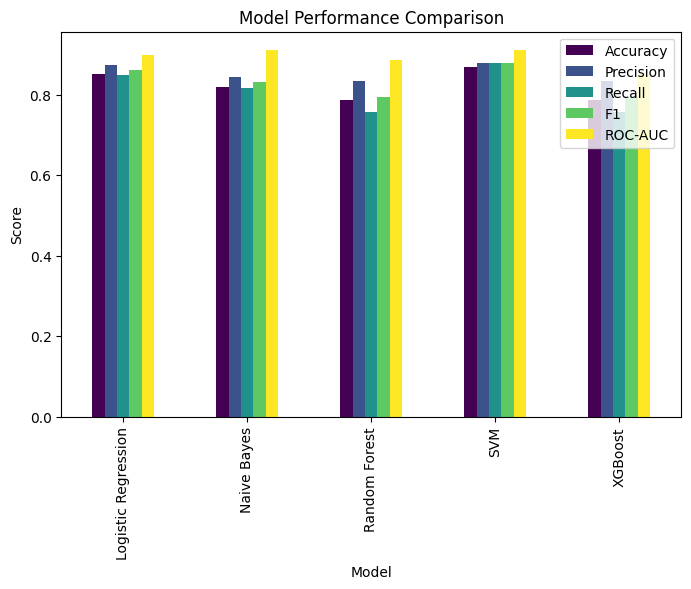

Best model (SVM) saved as 'heart_disease_svm_model.pkl'


In [1]:
# ==========================================
# FINAL HEART DISEASE PREDICTION PROJECT
# ==========================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. DATA LOADING & CLEANING
# ==========================================

df = pd.read_csv("heart.csv")
print("Dataset loaded successfully:", df.shape)

# Remove duplicate rows
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Target distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=df, palette='Set2')
plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

# ==========================================
# 2. PREPROCESSING & FEATURE ENGINEERING
# ==========================================

# Convert columns to categorical
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Create age groups
df['age_group'] = pd.cut(
    df['age'], bins=[0, 40, 55, 70, 100],
    labels=['Young', 'Middle-Aged', 'Senior', 'Elderly']
)
df['age_group'] = df['age_group'].astype(str)
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nPreprocessing complete.")
print("Training set:", X_train.shape, "Test set:", X_test.shape)

# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Correlation heatmap (numeric)
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm')
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

# Chest pain type vs target
sns.countplot(x='cp', hue='target', data=df, palette='Set1')
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

# Maximum heart rate distribution by target
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette='Set2')
plt.title("Maximum Heart Rate by Heart Disease")
plt.show()

# ==========================================
# 4. MODEL TRAINING
# ==========================================

# Baseline models
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

nb = GaussianNB()
nb.fit(X_train, y_train)

# Advanced models with hyperparameter tuning
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators': [100, 200], 'max_depth': [4, 6, 8]}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)

# SVM
svm = SVC(probability=True, random_state=42)
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
print("Best SVM Params:", svm_grid.best_params_)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost Params:", xgb_grid.best_params_)

# ==========================================
# 5. MODEL EVALUATION
# ==========================================

models = {
    "Logistic Regression": log_reg,
    "Naive Bayes": nb,
    "Random Forest": best_rf,
    "SVM": best_svm,
    "XGBoost": best_xgb
}

results = []
for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs) if probs is not None else np.nan
    results.append([name, acc, prec, rec, f1, roc])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
print("\nModel Performance Summary:\n")
print(results_df)

# ROC Curves
plt.figure(figsize=(7, 5))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Confusion Matrix – Best Model (SVM)
best_model = best_svm
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – SVM")
plt.show()

# Feature Importance – XGBoost
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importances – XGBoost")
plt.show()

# Model comparison plot
results_df.set_index('Model').plot(kind='bar', figsize=(8,5), colormap='viridis')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# ==========================================
# 6. SAVE BEST MODEL
# ==========================================
joblib.dump(best_model, 'heart_disease_svm_model.pkl')
print("Best model (SVM) saved as 'heart_disease_svm_model.pkl'")
